In [1]:
# Import all the libraries we need for this task
# LogisticRegression is the model we are building
# classification_report gives us a full breakdown of how well the model did
# roc_curve and auc are for drawing the ROC curve graph
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_curve, auc)
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the churn dataset
df = pd.read_csv('churn-bigml-80.csv')

# Look at the first few rows
print("First 5 rows:")
print(df.head())
print()
print("Shape:", df.shape)
print()

# Check what we are trying to predict
print("Churn value counts:")
print(df['Churn'].value_counts())


First 5 rows:
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1       

In [5]:
# Preprocess the data
# Drop State column - it has too many unique values
df = df.drop('State', axis=1)

# Convert text columns to numbers
le = LabelEncoder()
df['International plan'] = le.fit_transform(df['International plan'])
df['Voice mail plan'] = le.fit_transform(df['Voice mail plan'])
df['Churn'] = le.fit_transform(df['Churn'])

# X is everything except Churn, y is what we want to predict
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale the numerical features so everything is on the same scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data is ready!")
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Data is ready!
Training size: (2132, 18)
Testing size: (534, 18)


In [6]:
# Build and train the Logistic Regression model
# max_iter=1000 --> give the model enough time to learn
model = LogisticRegression(max_iter=1000)

# Train the model on the training data
model.fit(X_train, y_train)

# Use the model to make predictions on the test data
y_pred = model.predict(X_test)

print("Model trained successfully!")
print()
print("First 10 predictions vs actual:")
for pred, actual in zip(y_pred[:10], y_test[:10]):
    result = "yes" if pred == actual else "no"
    print(f"Predicted: {'Churn' if pred == 1 else 'Stay'} | Actual: {'Churn' if actual == 1 else 'Stay'} {result}")

Model trained successfully!

First 10 predictions vs actual:
Predicted: Churn | Actual: Churn yes
Predicted: Stay | Actual: Stay yes
Predicted: Stay | Actual: Stay yes
Predicted: Stay | Actual: Churn no
Predicted: Stay | Actual: Churn no
Predicted: Stay | Actual: Stay yes
Predicted: Stay | Actual: Stay yes
Predicted: Stay | Actual: Stay yes
Predicted: Stay | Actual: Stay yes
Predicted: Stay | Actual: Stay yes


In [7]:
# Evaluate the model
# classification_report gives us accuracy, precision, recall and F1 score
# Accuracy - how many predictions were correct overall
# Precision - of all customers predicted to churn, how many actually did
# Recall - of all customers who actually churned, how many did we catch
# F1 score - a balance between precision and recall

print("Model Evaluation:")
print()
print(classification_report(y_test, y_pred, 
                            target_names=['Stay', 'Churn']))

# Confusion matrix shows us exactly where the model got confused
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()
print("True Negatives (predicted Stay, actually Stay):", cm[0][0])
print("False Positives (predicted Churn, actually Stay):", cm[0][1])
print("False Negatives (predicted Stay, actually Churn):", cm[1][0])
print("True Positives (predicted Churn, actually Churn):", cm[1][1])

Model Evaluation:

              precision    recall  f1-score   support

        Stay       0.88      0.97      0.92       455
       Churn       0.56      0.23      0.32        79

    accuracy                           0.86       534
   macro avg       0.72      0.60      0.62       534
weighted avg       0.83      0.86      0.83       534

Confusion Matrix:
[[441  14]
 [ 61  18]]

True Negatives (predicted Stay, actually Stay): 441
False Positives (predicted Churn, actually Stay): 14
False Negatives (predicted Stay, actually Churn): 61
True Positives (predicted Churn, actually Churn): 18


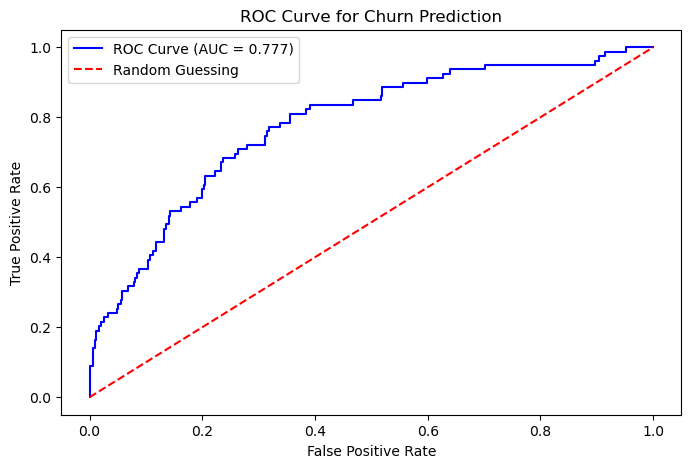

AUC Score: 0.777


In [8]:
# ROC curve
# The ROC curve shows how well the model can tell the difference between customers who churn and those who stay
# The higher the curve the better the model
# AUC score of 1.0 is perfect, 0.5 means the model is just guessing

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {round(roc_auc, 3)})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Churn Prediction')
plt.legend()
plt.show()

print("AUC Score:", round(roc_auc, 3))

In [9]:
# Interpret odds ratio
# Odd ratio - shows each feature affects chance of churning
# val>1 - feature increases chance of churning
# val < 1 - feature decreaases chance of churning

feature_names = df.drop('Churn', axis=1).columns 
odd_ratios = np.exp(model.coef_[0])

print("Odds ratios for each feature:")
for feature, odds in zip(feature_names, odd_ratios):
    print(f"{feature}: {round(odds,3)}")

Odds ratios for each feature:
Account length: 1.043
Area code: 0.948
International plan: 1.947
Voice mail plan: 0.466
Number vmail messages: 1.389
Total day minutes: 1.452
Total day calls: 1.078
Total day charge: 1.451
Total eve minutes: 1.154
Total eve calls: 1.015
Total eve charge: 1.152
Total night minutes: 1.079
Total night calls: 0.965
Total night charge: 1.077
Total intl minutes: 1.153
Total intl calls: 0.756
Total intl charge: 1.166
Customer service calls: 1.876
